First Importing All The Necesary Dependencies

In [107]:
import os
import xml.etree.ElementTree as ET
from collections import Counter 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm
import cv2
import random



Assigning Folder Path 

In [108]:
Dataset_Folder = r"C:\Users\kiran\Downloads\Military-Camouflage-MHCD2022\Military-Camouflage-MHCD2022"
Images_Path = os.path.join(Dataset_Folder, "JPEGImages")
Annotations_Path = os.path.join(Dataset_Folder, "Annotations")



In [109]:
images = os.listdir(Images_Path)
annotations = os.listdir(Annotations_Path)

print(f"Total Images : {len(images)}")
print(f"Total Annotations : {len(annotations)}")

Total Images : 3000
Total Annotations : 3000


In [110]:
widths = []
heights = [] 

for img_name in tqdm(images):
    img_path = os.path.join(Images_Path, img_name)
    img = Image.open(img_path)
    width, height = img.size
    widths.append(width)
    heights.append(height)

100%|██████████| 3000/3000 [00:00<00:00, 4671.68it/s]


In [111]:
print(f"Average Width : {np.mean(widths)}")
print(f"Average Height : {np.mean(heights)}")

print(f"Minimum Width : {np.min(widths)}")
print(f"Minimum Height : {np.min(heights)}")

print(f"Maximum Width : {np.max(widths)}")
print(f"Maximum Height : {np.max(heights)}")

Average Width : 714.098
Average Height : 434.3403333333333
Minimum Width : 200
Minimum Height : 146
Maximum Width : 2810
Maximum Height : 1880


<Figure size 1200x500 with 0 Axes>

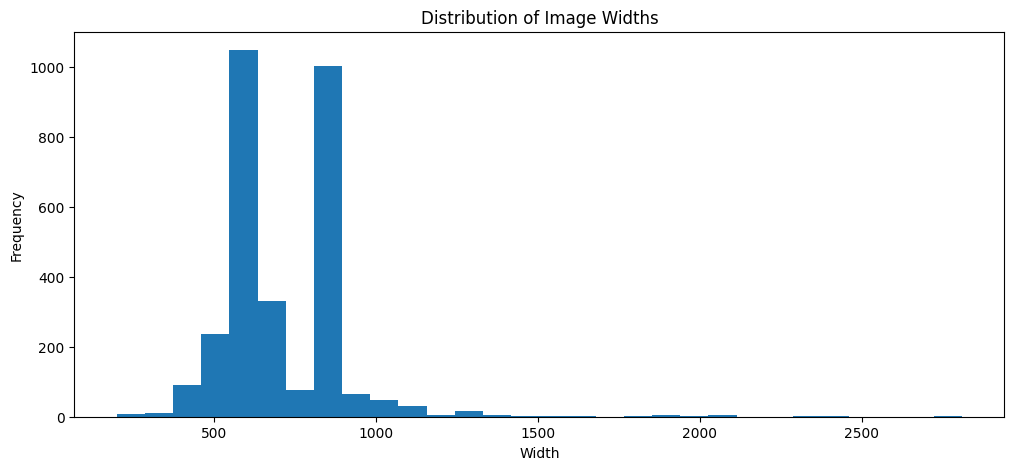

<Figure size 1200x500 with 0 Axes>

In [112]:
plt.figure(figsize=(12, 5))
plt.hist(widths, bins=30)
plt.title("Distribution of Image Widths")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.figure(figsize=(12, 5))

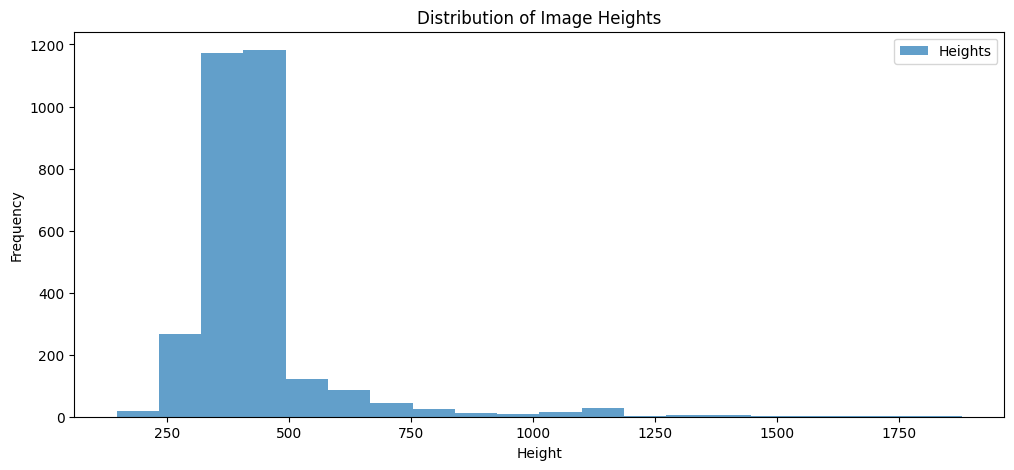

In [113]:
plt.figure(figsize=(12, 5))
plt.hist(heights, bins=20, alpha=0.7, label='Heights')
plt.title("Distribution of Image Heights")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.legend()
plt.show()

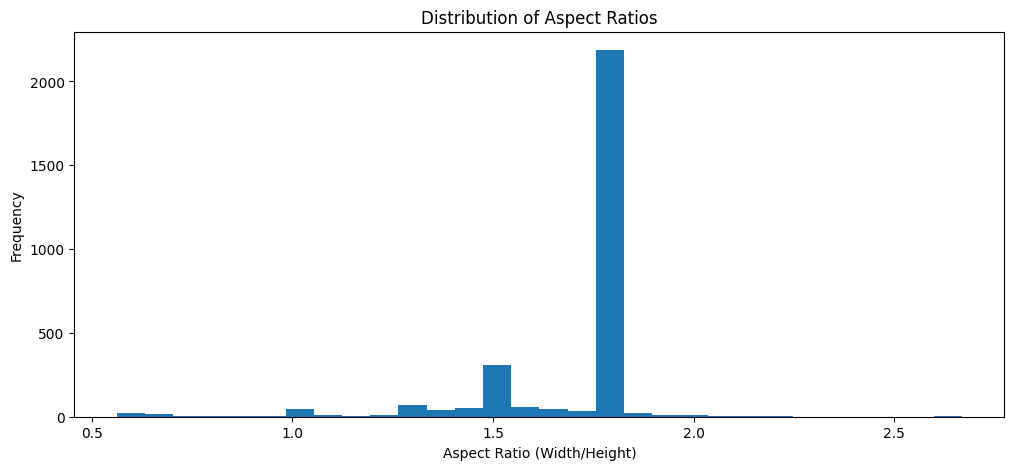

In [114]:
aspect_ratios=[]
for w, h in zip(widths, heights):
    aspect_ratios.append(w/h)

plt.figure(figsize=(12, 5))
plt.hist(aspect_ratios, bins=30)
plt.title("Distribution of Aspect Ratios")
plt.xlabel("Aspect Ratio (Width/Height)")
plt.ylabel("Frequency")
plt.show() 


In [115]:
class_counts = Counter()

all_boxes =[]

for xml_files in tqdm(annotations):
    xml_path = os.path.join(Annotations_Path, xml_files)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    for obj in root.findall('object'):
        class_name = obj.find('name').text
        class_counts[class_name] += 1
        
        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)
        
        all_boxes.append((class_name, xmin, ymin, xmax, ymax))

100%|██████████| 3000/3000 [00:00<00:00, 15066.14it/s]


In [116]:
class_counts

Counter({'person': 3364,
         'tank': 399,
         'aeroplane': 286,
         'military vehicle': 198,
         'warship': 154})

In [117]:
class_df = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])
class_df 

,Class,Count
0,person,3364
1,military vehicle,198
2,tank,399
3,aeroplane,286
4,warship,154


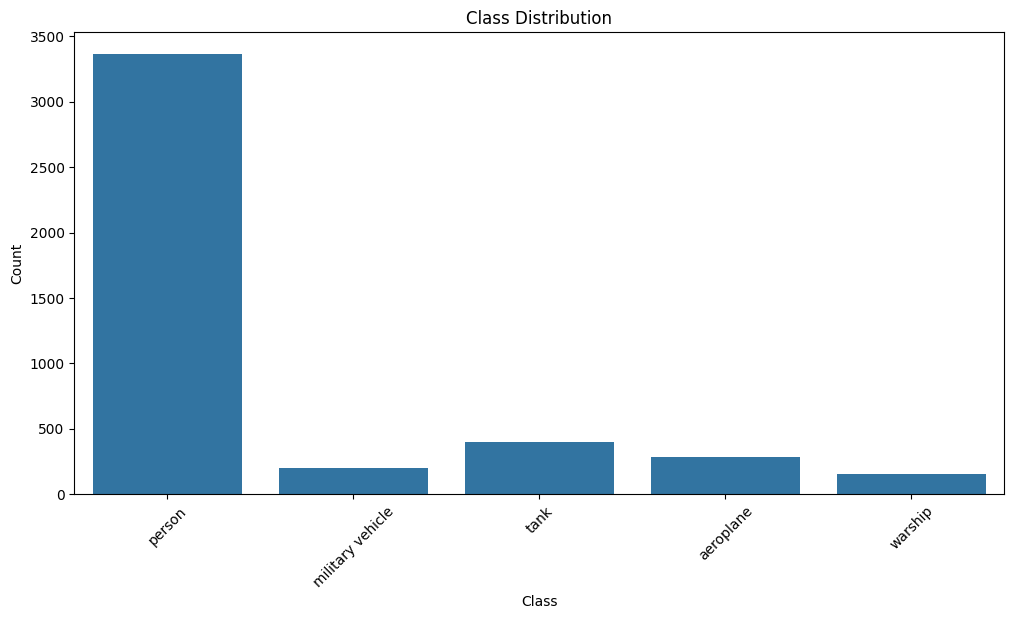

In [118]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Class', y='Count', data=class_df)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

In [119]:
from collections import defaultdict
objects_per_image = defaultdict(int)
for xml_files in tqdm(annotations):
    xml_path = os.path.join(Annotations_Path, xml_files)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    count = len(root.findall('object'))
    objects_per_image[xml_files] = count

100%|██████████| 3000/3000 [00:00<00:00, 16700.17it/s]


In [120]:
counts = list(objects_per_image.values())

print(f"Average Objects per Image : {np.mean(counts)}")
print(f"Maximum Objects per Image : {np.max(counts)}")
print(f"Minimum Objects per Image : {np.min(counts)}")

Average Objects per Image : 1.467
Maximum Objects per Image : 16
Minimum Objects per Image : 1


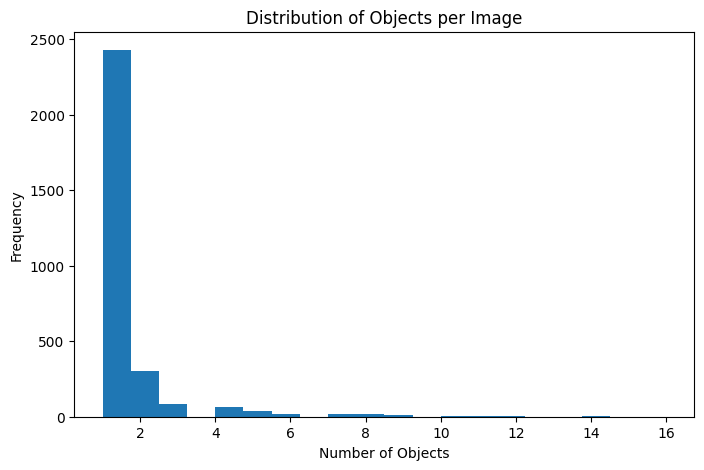

In [121]:
plt.figure(figsize=(8,5))
plt.hist(counts, bins=20)
plt.title("Distribution of Objects per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Frequency")
plt.show()

In [122]:
box_widths=[]
box_heights=[]
box_areas=[]

for xml_files in tqdm(annotations):
    xml_path = os.path.join(Annotations_Path, xml_files)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    for obj in root.findall('object'):
        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)
        
        width = xmax - xmin
        height = ymax - ymin
        area = width * height
        
        box_widths.append(width)
        box_heights.append(height)
        box_areas.append(area)

100%|██████████| 3000/3000 [00:00<00:00, 16996.13it/s]


In [123]:
print("Average Box Area : ", np.mean(box_areas))
print("Median Box Height : ", np.median(box_areas))
print("Minimum Box Area : ", np.min(box_areas))
print("Maximum Box Area : ", np.max(box_areas))

Average Box Area :  35577.03885480572
Median Box Height :  6048.0
Minimum Box Area :  96
Maximum Box Area :  1804278


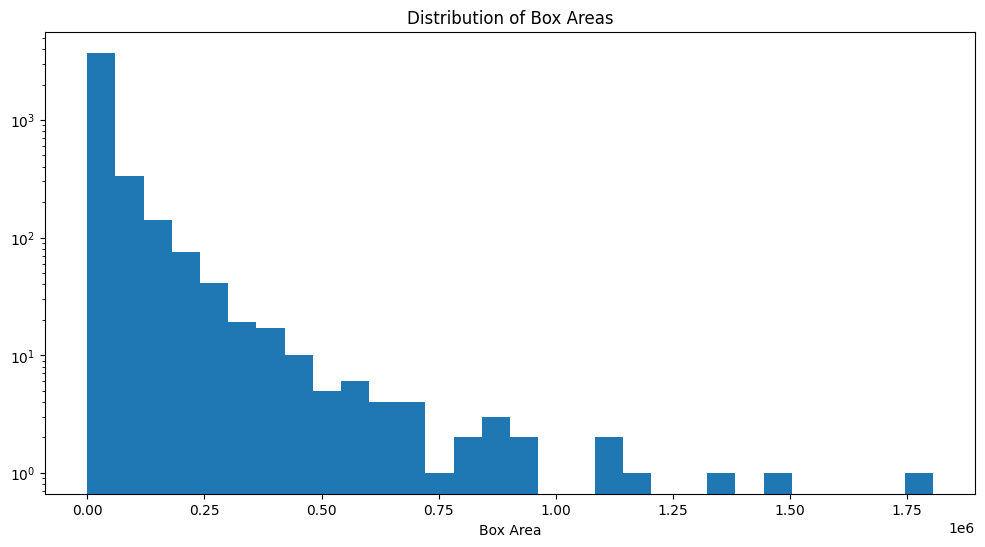

In [124]:
plt.figure(figsize=(12, 6))
plt.hist(box_areas, bins=30)
plt.title("Distribution of Box Areas")
plt.xlabel("Box Area")
plt.yscale('log')
plt.show()

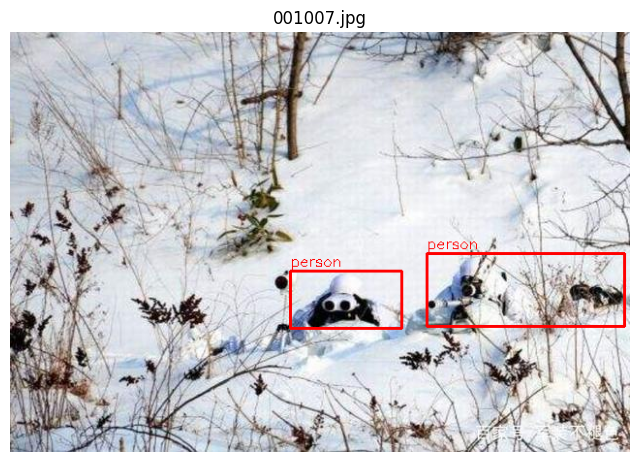

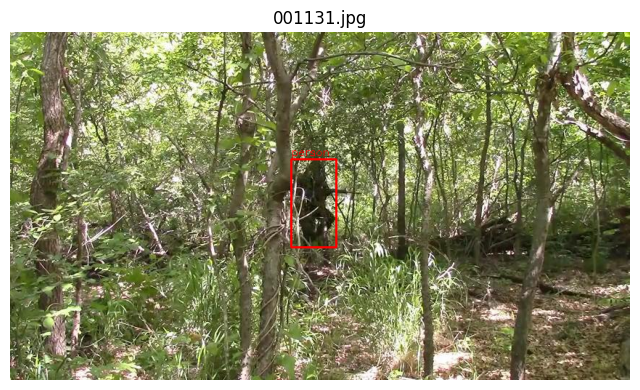

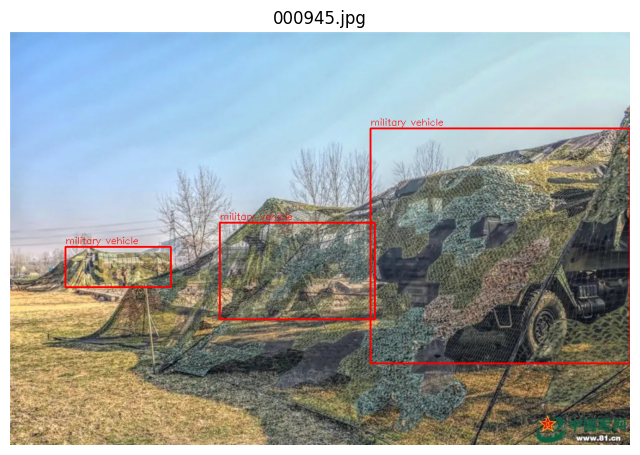

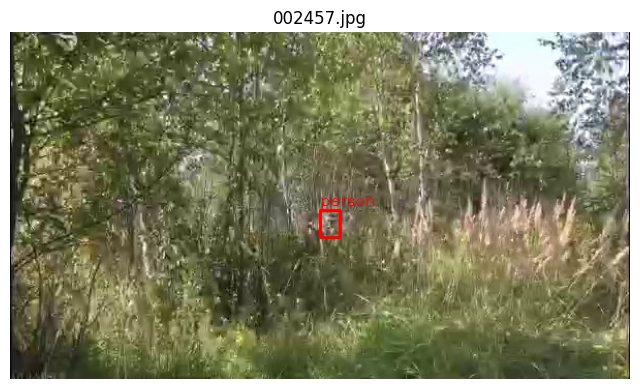

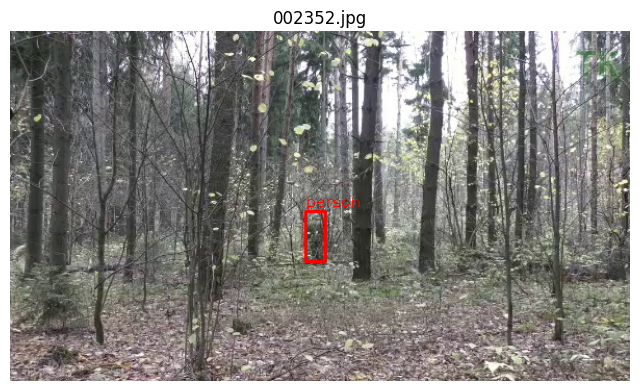

In [139]:
sample_xmls = random.sample(annotations,5)
for xml_file in sample_xmls:

    xml_path = os.path.join(Annotations_Path, xml_file)

    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Ignore XML filename field
    image_name = xml_file.replace(".xml", ".jpg")

    img_path = os.path.join(Images_Path, image_name)

    image = cv2.imread(img_path)

    if image is None:
        print(f"Missing image: {image_name}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for obj in root.findall("object"):

        label = obj.find("name").text

        bbox = obj.find("bndbox")

        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)

        cv2.putText(
            image,
            label,
            (xmin, ymin - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            1
        )

    plt.figure(figsize=(8,6))
    plt.imshow(image)
    plt.title(image_name)
    plt.axis("off")
    plt.show()

In [126]:
records = []

for xml_file in tqdm(annotations):
    tree = ET.parse(os.path.join(Annotations_Path, xml_file))
    root = tree.getroot()

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        bbox = obj.find("bndbox")
        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        area = (xmax - xmin) * (ymax - ymin)

        records.append([class_name, area])
        
        df_area = pd.DataFrame(records, columns=['Class', 'Area'])


100%|██████████| 3000/3000 [00:02<00:00, 1350.14it/s]


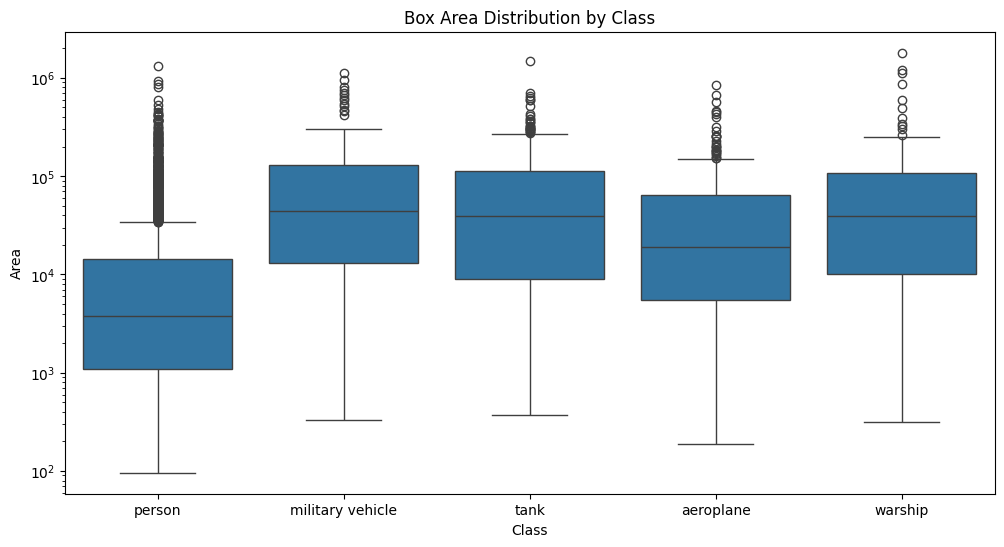

In [127]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Class', y='Area', data=df_area)

plt.yscale('log')
plt.title("Box Area Distribution by Class")     
plt.show()

In [129]:
from collections import defaultdict
class_image_counts = defaultdict(int)
for xml_file in tqdm(annotations):
    tree = ET.parse(os.path.join(Annotations_Path, xml_file))
    root = tree.getroot()
    classes_in_image = set()
    
    for obj in root.findall("object"):
        class_name = obj.find("name").text
        classes_in_image.add(class_name)
    
    for cls in classes_in_image:
        class_image_counts[cls] += 1
print(class_image_counts)

100%|██████████| 3000/3000 [00:00<00:00, 16730.79it/s]

defaultdict(<class 'int'>, {'person': 2624, 'military vehicle': 125, 'tank': 236, 'aeroplane': 135, 'warship': 85})
